filename    folder  label label_name  img_width  img_height  file_size_kb
   1.png with_mask      1  with_mask        128         128         35.15
  10.png with_mask      1  with_mask        128         128         18.75
 100.png with_mask      1  with_mask        128         128         19.57
1000.png with_mask      1  with_mask        128         128         22.54
1001.png with_mask      1  with_mask        128         128         22.89
1002.png with_mask      1  with_mask        128         128         28.96
1003.png with_mask      1  with_mask        128         128         21.29
1004.png with_mask      1  with_mask        128         128         25.39
1005.png with_mask      1  with_mask        128         128         23.94
1006.png with_mask      1  with_mask        128         128         21.73
filename         object
folder           object
label             int64
label_name       object
img_width         int64
img_height        int64
file_size_kb    float64
       img_width  

Feature matrix: (8982, 8100)  |  HOG vector size: 8100
Train: 7185  |  Test: 1797
PCA: 8100 → 300 features  |  Variance retained: 63.9%
Train Accuracy : 100.00%
Test  Accuracy : 96.88%
              precision    recall  f1-score   support

without_mask       0.99      0.96      0.98      1198
   with_mask       0.92      0.99      0.95       599

    accuracy                           0.97      1797
   macro avg       0.96      0.97      0.97      1797
weighted avg       0.97      0.97      0.97      1797

confusion_matrix.png  → saved
sample_predictions.png → saved
facemask_svm_model.pkl → saved
preprocessed_data.pkl  → saved


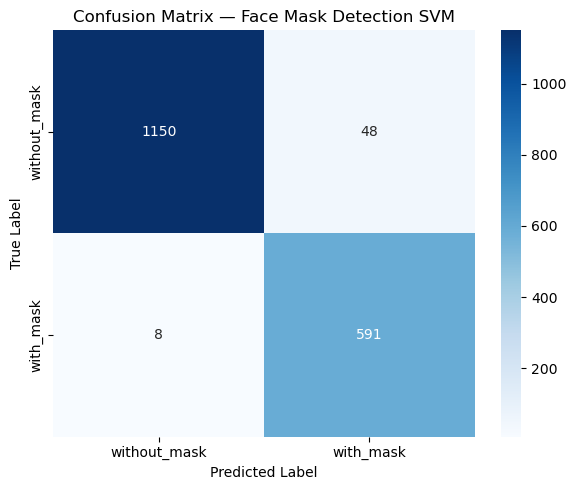

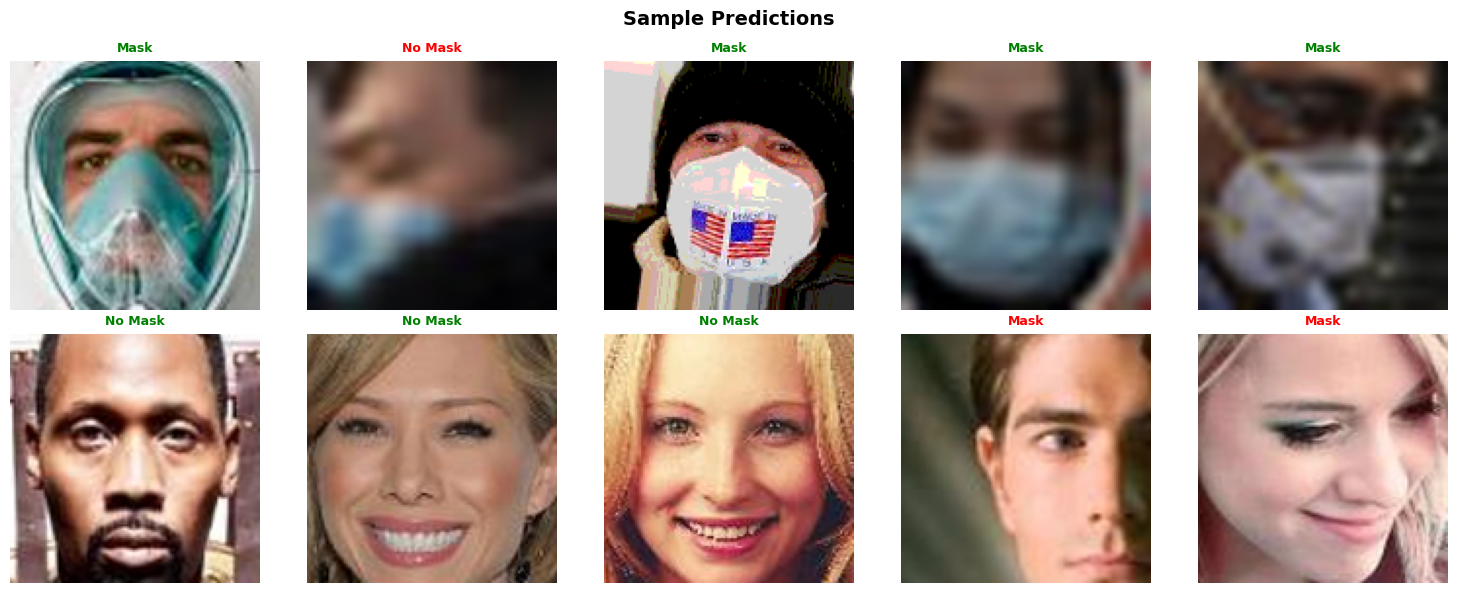

In [28]:
"""
Face Mask Detection using SVM
Option B: Image Classification using Support Vector Machine

Problem  : Detect whether a person is wearing a face mask
Input    : Facial images (with_mask / without_mask / mask_weared_incorrect)
Output   : Binary label — 1 (with_mask) or 0 (without_mask)
Solution : SVM with RBF kernel on HOG feature vectors
"""

import os
import numpy as np
import pandas as pd
import cv2
import pickle
from datetime import datetime
from tqdm import tqdm

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from skimage.feature import hog
import matplotlib.pyplot as plt
import seaborn as sns

# ─── CONFIG ───────────────────────────────────────────────────────────────────
DATASET_FOLDERS = {
    'with_mask':             r"C:\Users\David\Desktop\Neural Network\midterm 2\Dataset\with_mask",
    'without_mask':          r"C:\Users\David\Desktop\Neural Network\midterm 2\Dataset\without_mask",
    'mask_weared_incorrect': r"C:\Users\David\Desktop\Neural Network\midterm 2\Dataset\mask_weared_incorrect",
}
LABEL_MAP      = {'with_mask': 1, 'without_mask': 0, 'mask_weared_incorrect': 0}
IMAGE_SIZE     = (128, 128)
TEST_SIZE      = 0.2
RANDOM_STATE   = 42
IMG_EXTS       = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
PCA_COMPONENTS = 300
# ──────────────────────────────────────────────────────────────────────────────


# =============================================================================
# PART 1: DATA EXPLORATION AND CLEANING
# =============================================================================

# Build a metadata DataFrame for exploration
records = []
for folder_name, folder_path in DATASET_FOLDERS.items():
    for fname in os.listdir(folder_path):
        if os.path.splitext(fname.lower())[1] in IMG_EXTS:
            fpath = os.path.join(folder_path, fname)
            img   = cv2.imread(fpath)
            h, w  = (img.shape[:2] if img is not None else (None, None))
            records.append({
                'filename':    fname,
                'folder':      folder_name,
                'label':       LABEL_MAP[folder_name],
                'label_name':  'with_mask' if LABEL_MAP[folder_name] == 1 else 'without_mask',
                'img_width':   w,
                'img_height':  h,
                'file_size_kb': round(os.path.getsize(fpath) / 1024, 2),
            })

df = pd.DataFrame(records)

# Display first 10 rows, data types, and summary statistics
print(df.head(10).to_string(index=False))
print(df.dtypes.to_string())
print(df[['img_width', 'img_height', 'file_size_kb']].describe().round(2).to_string())
print(df['folder'].value_counts().to_string())
print(df.isnull().sum().to_string())

# Remove unreadable images, duplicates, and tiny outliers (<20px)
df = df.dropna(subset=['img_width', 'img_height'])
df = df.drop_duplicates(subset=['filename'])
df = df[(df['img_width'] >= 20) & (df['img_height'] >= 20)]

print(f"Clean dataset: {len(df)} images  |  with_mask: {(df['label']==1).sum()}  |  without_mask: {(df['label']==0).sum()}")


# =============================================================================
# PART 2B: IMAGE PREPROCESSING
# =============================================================================

def preprocess_image(img_bgr, target_size=IMAGE_SIZE):
    # Step 1: Convert to grayscale
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Step 2: Resize to standard dimensions
    resized = cv2.resize(gray, target_size)

    # Step 3: Normalize pixel values to [0, 1]
    normalized = resized / 255.0

    # Step 4: Histogram equalization for contrast normalization
    equalized = cv2.equalizeHist((normalized * 255).astype(np.uint8))

    # Step 5: HOG feature extraction — outputs a flattened 1D feature vector
    feature_vector = hog(
        equalized,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
    )
    return feature_vector


# Extract HOG features from all images
X, y = [], []
for folder_name, folder_path in DATASET_FOLDERS.items():
    label = LABEL_MAP[folder_name]
    files = [f for f in os.listdir(folder_path)
             if os.path.splitext(f.lower())[1] in IMG_EXTS]
    for fname in tqdm(files, desc=f"  {folder_name}", leave=False):
        img = cv2.imread(os.path.join(folder_path, fname))
        if img is None:
            continue
        X.append(preprocess_image(img))
        y.append(label)

X, y = np.array(X), np.array(y)
print(f"Feature matrix: {X.shape}  |  HOG vector size: {X.shape[1]}")


# 80/20 train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

# Standardize features then reduce dimensions with PCA
scaler      = StandardScaler()
X_train_s   = scaler.fit_transform(X_train)
X_test_s    = scaler.transform(X_test)

pca         = PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca  = pca.transform(X_test_s)

print(f"PCA: {X.shape[1]} → {PCA_COMPONENTS} features  |  Variance retained: {pca.explained_variance_ratio_.sum()*100:.1f}%")


# =============================================================================
# SVM TRAINING  (RBF kernel, balanced class weights for imbalanced dataset)
# =============================================================================

svm = SVC(kernel='rbf', C=5, gamma='scale', probability=True,
          class_weight='balanced', random_state=RANDOM_STATE)
svm.fit(X_train_pca, y_train)


# =============================================================================
# EVALUATION
# =============================================================================

y_pred    = svm.predict(X_test_pca)
train_acc = accuracy_score(y_train, svm.predict(X_train_pca))
test_acc  = accuracy_score(y_test, y_pred)

print(f"Train Accuracy : {train_acc*100:.2f}%")
print(f"Test  Accuracy : {test_acc*100:.2f}%")
print(classification_report(y_test, y_pred, target_names=['without_mask', 'with_mask']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['without_mask', 'with_mask'],
            yticklabels=['without_mask', 'with_mask'])
plt.title('Confusion Matrix — Face Mask Detection SVM')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=200)

# Sample predictions grid (green = correct, red = misclassified)
sample_imgs, sample_labels = [], []
for folder_name, folder_path in DATASET_FOLDERS.items():
    for fname in os.listdir(folder_path)[:5]:
        if os.path.splitext(fname.lower())[1] in IMG_EXTS:
            img = cv2.imread(os.path.join(folder_path, fname))
            if img is not None:
                sample_imgs.append(img)
                sample_labels.append(LABEL_MAP[folder_name])

sample_preds = svm.predict(
    pca.transform(scaler.transform(
        np.array([preprocess_image(img) for img in sample_imgs])
    ))
)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Predictions', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    if i >= len(sample_imgs):
        ax.axis('off'); continue
    ax.imshow(cv2.cvtColor(cv2.resize(sample_imgs[i], (128, 128)), cv2.COLOR_BGR2RGB))
    pred  = sample_preds[i]
    color = 'green' if pred == sample_labels[i] else 'red'
    ax.set_title('Mask' if pred == 1 else 'No Mask', color=color, fontsize=9, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)

print("confusion_matrix.png  → saved")
print("sample_predictions.png → saved")


# =============================================================================
# SAVE MODEL
# =============================================================================

model_data = {
    'model': svm, 'scaler': scaler, 'pca': pca,
    'image_size': IMAGE_SIZE,
    'train_accuracy': train_acc, 'test_accuracy': test_acc,
    'X_test': X_test_pca, 'y_test': y_test,
    'class_names': ['without_mask', 'with_mask'],
    'training_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'total_training_samples': len(X_train),
    'total_test_samples': len(X_test),
}
with open('facemask_svm_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

with open('preprocessed_data.pkl', 'wb') as f:
    pickle.dump({'X_train': X_train_pca, 'X_test': X_test_pca,
                 'y_train': y_train, 'y_test': y_test,
                 'scaler': scaler, 'pca': pca, 'image_size': IMAGE_SIZE}, f)

print("facemask_svm_model.pkl → saved")
print("preprocessed_data.pkl  → saved")

Model loaded | Original test accuracy: 96.88%
Test set size: 1797 samples

Trial  1: Acc= 96.0%  Prec= 96.1%  Rec= 96.0%  F1= 96.0%
Trial  2: Acc= 98.0%  Prec= 98.1%  Rec= 98.0%  F1= 98.0%
Trial  3: Acc= 96.0%  Prec= 96.4%  Rec= 96.0%  F1= 96.0%
Trial  4: Acc= 97.0%  Prec= 97.2%  Rec= 97.0%  F1= 97.0%
Trial  5: Acc= 96.0%  Prec= 96.4%  Rec= 96.0%  F1= 96.0%
Trial  6: Acc= 98.0%  Prec= 98.1%  Rec= 98.0%  F1= 98.0%
Trial  7: Acc= 95.0%  Prec= 95.7%  Rec= 95.0%  F1= 95.1%
Trial  8: Acc= 96.0%  Prec= 96.5%  Rec= 96.0%  F1= 96.1%
Trial  9: Acc= 97.0%  Prec= 97.0%  Rec= 97.0%  F1= 97.0%
Trial 10: Acc= 98.0%  Prec= 98.2%  Rec= 98.0%  F1= 98.0%
Trial 11: Acc= 94.0%  Prec= 95.1%  Rec= 94.0%  F1= 94.2%
Trial 12: Acc= 96.0%  Prec= 96.1%  Rec= 96.0%  F1= 96.0%
Trial 13: Acc= 99.0%  Prec= 99.0%  Rec= 99.0%  F1= 99.0%
Trial 14: Acc= 94.0%  Prec= 94.6%  Rec= 94.0%  F1= 94.1%
Trial 15: Acc= 96.0%  Prec= 96.2%  Rec= 96.0%  F1= 96.0%
Trial 16: Acc= 95.0%  Prec= 95.3%  Rec= 95.0%  F1= 95.1%
Trial 17: Acc

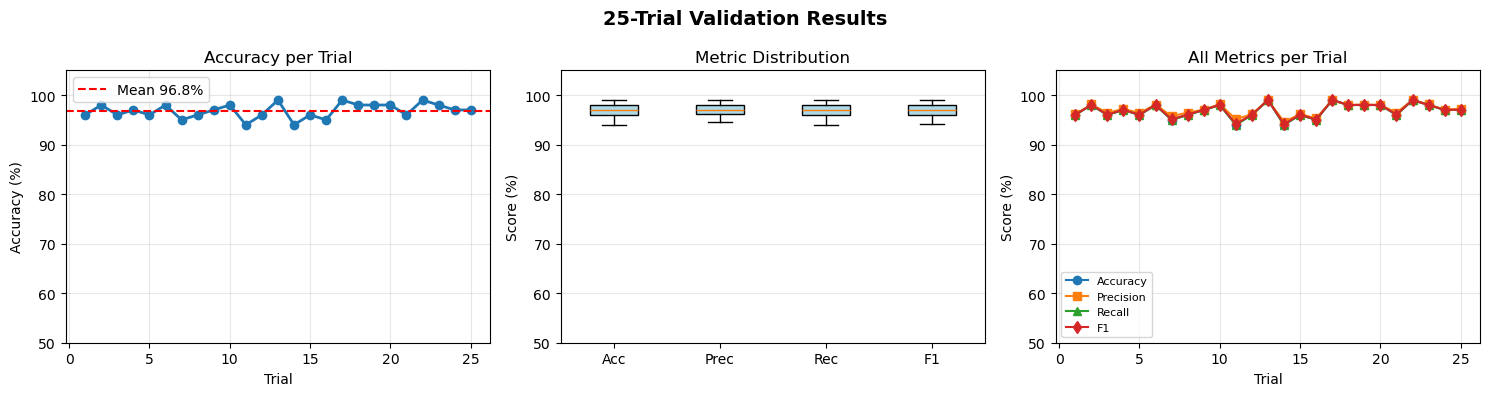

In [29]:
"""
Face Mask Detection - Validation Script (25 Trials)
"""

import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load model & data
with open('facemask_svm_model.pkl', 'rb') as f:
    model_data = pickle.load(f)
with open('preprocessed_data.pkl', 'rb') as f:
    preprocessed = pickle.load(f)

svm_model = model_data['model']
X_test    = model_data['X_test']
y_test    = model_data['y_test']

print(f"Model loaded | Original test accuracy: {model_data['test_accuracy']*100:.2f}%")
print(f"Test set size: {len(X_test)} samples\n")

# ── 25 Validation Trials ──────────────────────────────────────────────────────
NUM_TRIALS  = 25
SAMPLE_SIZE = min(100, len(X_test))

np.random.seed(42)
results = []

for trial in range(1, NUM_TRIALS + 1):
    idx     = np.random.choice(len(X_test), SAMPLE_SIZE, replace=False)
    y_pred  = svm_model.predict(X_test[idx])
    y_true  = y_test[idx]

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    results.append({'Trial': trial, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})
    print(f"Trial {trial:2d}: Acc={acc*100:5.1f}%  Prec={prec*100:5.1f}%  Rec={rec*100:5.1f}%  F1={f1*100:5.1f}%")

df = pd.DataFrame(results)

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n── Summary (Mean ± Std) " + "─"*46)
for col in ['Accuracy', 'Precision', 'Recall', 'F1']:
    print(f"  {col:<10}: {df[col].mean()*100:.2f}% ± {df[col].std()*100:.2f}%")

df.to_csv('validation_results.csv', index=False)
print("\nResults saved → validation_results.csv")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('25-Trial Validation Results', fontsize=14, fontweight='bold')

# Accuracy line
axes[0].plot(df['Trial'], df['Accuracy']*100, marker='o', linewidth=2)
axes[0].axhline(df['Accuracy'].mean()*100, color='r', linestyle='--',
                label=f"Mean {df['Accuracy'].mean()*100:.1f}%")
axes[0].set(title='Accuracy per Trial', xlabel='Trial', ylabel='Accuracy (%)', ylim=[50, 105])
axes[0].legend(); axes[0].grid(alpha=0.3)

# Box plot
bp = axes[1].boxplot([df[c]*100 for c in ['Accuracy','Precision','Recall','F1']],
                     tick_labels=['Acc','Prec','Rec','F1'], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[1].set(title='Metric Distribution', ylabel='Score (%)', ylim=[50, 105])
axes[1].grid(alpha=0.3, axis='y')

# All metrics
for col, marker in zip(['Accuracy','Precision','Recall','F1'], ['o','s','^','d']):
    axes[2].plot(df['Trial'], df[col]*100, marker=marker, label=col, linewidth=1.5)
axes[2].set(title='All Metrics per Trial', xlabel='Trial', ylabel='Score (%)', ylim=[50, 105])
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('validation_plots.png', dpi=200, bbox_inches='tight')
print("Plots saved   → validation_plots.png")

Model loaded | Accuracy: 96.88%
Prediction  : WITHOUT_MASK
Confidence  : 96.8%


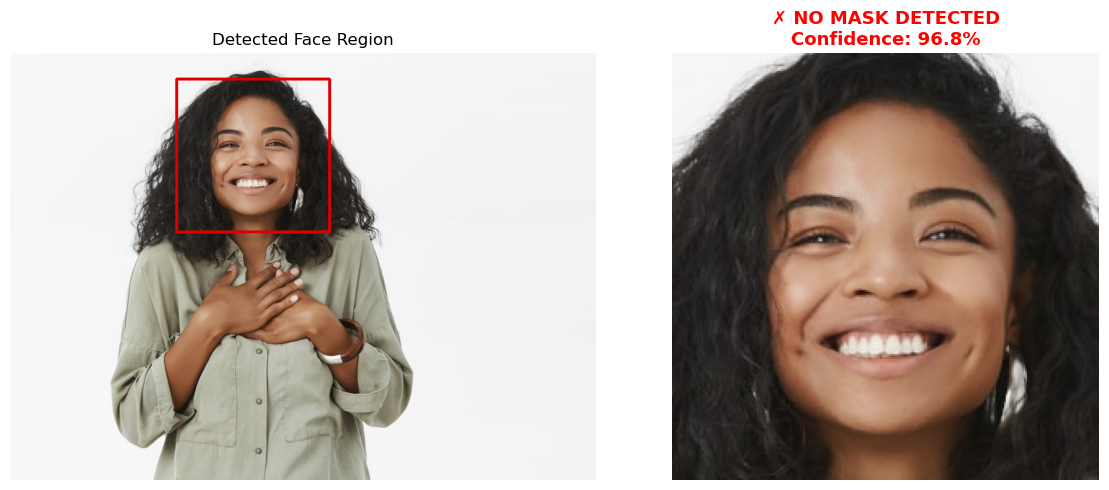

Result saved → prediction_20260425_235235.png


In [30]:
"""
Face Mask Detection - Inference Script
Detects face region first, then classifies mask/no-mask on the crop.
"""

import cv2
import pickle
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from skimage.feature import hog

# ─── INSERT YOUR IMAGE PATH HERE ──────────────────────────────────────────────
IMAGE_PATH = "test/wt1.jpg"
# ──────────────────────────────────────────────────────────────────────────────

# Load model
with open('facemask_svm_model.pkl', 'rb') as f:
    model_data = pickle.load(f)

svm_model   = model_data['model']
scaler      = model_data['scaler']
pca         = model_data['pca']
image_size  = model_data['image_size']
class_names = model_data['class_names']

print(f"Model loaded | Accuracy: {model_data['test_accuracy']*100:.2f}%")

# Load OpenCV face detector (built-in, no download needed)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')


def extract_features(img_bgr, target_size):
    """Match exact preprocessing used during training."""
    img  = cv2.resize(img_bgr, target_size)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)
    return hog(gray, orientations=9, pixels_per_cell=(8, 8),
               cells_per_block=(2, 2), block_norm='L2-Hys')


def detect_face(img_bgr):
    """
    Detect the largest face in the image and return its crop.
    Falls back to full image if no face is found.
    """
    gray   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    faces  = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(60, 60)
    )

    if len(faces) == 0:
        print("  No face detected — using full image (results may be less accurate)")
        return img_bgr, None

    # Pick the largest detected face
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])

    # Add 20% padding around the face for context (nose/mouth area)
    pad_x = int(w * 0.2)
    pad_y = int(h * 0.2)
    x1 = max(0, x - pad_x)
    y1 = max(0, y - pad_y)
    x2 = min(img_bgr.shape[1], x + w + pad_x)
    y2 = min(img_bgr.shape[0], y + h + pad_y)

    return img_bgr[y1:y2, x1:x2], (x1, y1, x2, y2)


def predict(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not read: {image_path}")

    # Step 1: Crop to face region
    face_crop, bbox = detect_face(img)

    # Step 2: Extract HOG → scale → PCA → predict
    features = extract_features(face_crop, image_size).reshape(1, -1)
    X_scaled = scaler.transform(features)
    X_pca    = pca.transform(X_scaled)

    prediction  = svm_model.predict(X_pca)[0]
    probability = svm_model.predict_proba(X_pca)[0][prediction]
    label       = class_names[prediction]

    return img, face_crop, bbox, prediction, label, probability


def show_result(img, face_crop, bbox, prediction, label, confidence):
    color  = 'green' if prediction == 1 else 'red'
    status = "✓ MASK DETECTED" if prediction == 1 else "✗ NO MASK DETECTED"

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Left: full image with bounding box drawn
    display = cv2.cvtColor(img.copy(), cv2.COLOR_BGR2RGB)
    if bbox:
        x1, y1, x2, y2 = bbox
        cv2.rectangle(display, (x1, y1), (x2, y2),
                      (0, 200, 0) if prediction == 1 else (220, 0, 0), 3)
    axes[0].imshow(display)
    axes[0].set_title("Detected Face Region", fontsize=12)
    axes[0].axis('off')

    # Right: face crop that was actually classified
    axes[1].imshow(cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"{status}\nConfidence: {confidence:.1%}",
                      fontsize=13, fontweight='bold', color=color)
    axes[1].axis('off')

    plt.tight_layout()
    out = f"prediction_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Result saved → {out}")


# Run
img, face_crop, bbox, prediction, label, confidence = predict(IMAGE_PATH)
print(f"Prediction  : {label.upper()}")
print(f"Confidence  : {confidence:.1%}")
show_result(img, face_crop, bbox, prediction, label, confidence)